# Simple CNN Model - Cats vs Dogs

In this notebook, we build and train a first simple Convolutional Neural Network (CNN) model.

The goal is to classify images as either cat or dog.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# Project paths

current_path = Path.cwd()

if (current_path / "data").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parents[1]

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "dogcat"

TRAIN_DIR = DATA_DIR / "train"
VALIDATION_DIR = DATA_DIR / "validation"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

print("Project root:", PROJECT_ROOT)
print("Train directory exists:", TRAIN_DIR.exists())
print("Validation directory exists:", VALIDATION_DIR.exists())

Project root: c:\Users\mahta\aidev\cats-dogs-cnn-classifier
Train directory exists: True
Validation directory exists: True


In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
print("Class names:", class_names)

Found 25000 files belonging to 2 classes.
Found 8000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [14]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [15]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Simple CNN architecture

The first model is a simple CNN model.

It uses three convolutional blocks.  
Each block contains a Conv2D layer followed by a MaxPooling2D layer.

The Conv2D layers learn visual patterns from the images, such as edges, textures and shapes.  
The MaxPooling2D layers reduce the size of the feature maps and keep the most important information.

After the convolutional part, the Flatten layer converts the extracted feature maps into a one-dimensional vector.  
The Dense layers then use this information to make the final binary classification: cat or dog.

## Model summary interpretation

The simple CNN model takes images with the shape 128x128x3 as input.

The convolutional layers extract visual features such as edges, textures and shapes.  
The max pooling layers reduce the spatial size of the feature maps and keep the most important information.

After the convolutional part, the Flatten layer converts the final feature maps into a one-dimensional vector.  
The Dense layers then use this information to classify the image as either cat or dog.

The final layer has one neuron with a sigmoid activation function, which is suitable for binary classification.

In [16]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Model compilation

The model is compiled with the Adam optimizer and binary crossentropy loss.

Adam is a commonly used optimizer for neural networks.  
Binary crossentropy is used because this is a binary classification problem with two classes: cats and dogs.

Accuracy is used as the main metric to monitor how many images the model classifies correctly.

## First training run

The first training run uses a simple CNN model with a small number of epochs.

Since the model is trained locally on CPU, we start with only 3 epochs to check that the training process works correctly.

In [17]:
EPOCHS = 3

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 185ms/step - accuracy: 0.6912 - loss: 0.5720 - val_accuracy: 0.7830 - val_loss: 0.4584
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 178s 228ms/step - accuracy: 0.7917 - loss: 0.4434 - val_accuracy: 0.8338 - val_loss: 0.3687
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 228s 292ms/step - accuracy: 0.8358 - loss: 0.3692 - val_accuracy: 0.8746 - val_loss: 0.2938


## First training result

The first simple CNN model was trained for 3 epochs.

The model improved during training.  
Training accuracy increased from about 69% to 84%, and validation accuracy increased from about 78% to 87%.

This shows that the CNN model is learning useful visual patterns from the images.  
Since this is only the first simple model, the result is a strong baseline for further improvement.

In [20]:
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.69120,0.571966,0.783000,0.458447
1,0.79172,0.443388,0.833750,0.368709
2,0.83584,0.369233,0.874625,0.293811


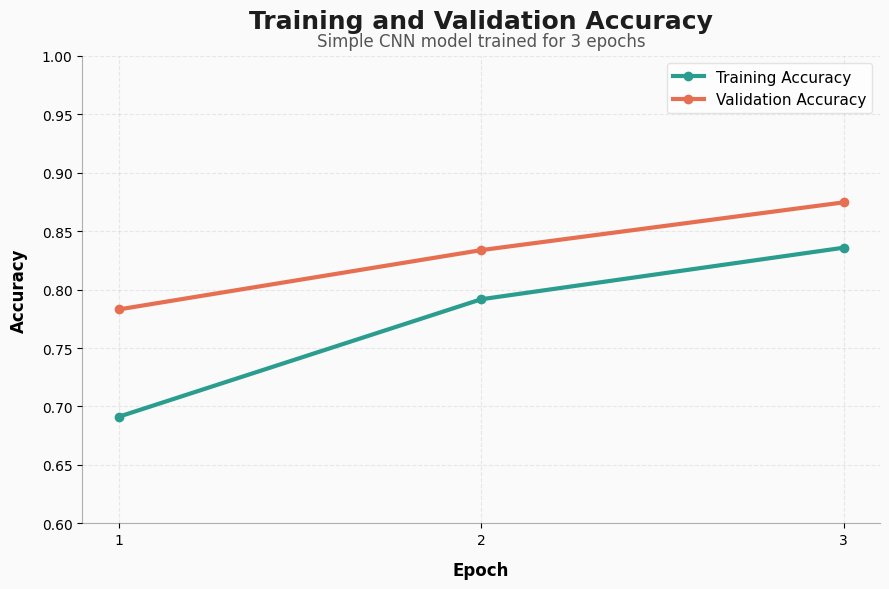

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.plot(
    history_df.index + 1,
    history_df["accuracy"],
    marker="o",
    linewidth=3,
    label="Training Accuracy",
    color="#2A9D8F"
)

ax.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    marker="o",
    linewidth=3,
    label="Validation Accuracy",
    color="#E76F51"
)

ax.set_title(
    "Training and Validation Accuracy",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Simple CNN model trained for 3 epochs",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_xlabel("Epoch", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Accuracy", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xticks(history_df.index + 1)
ax.set_ylim(0.60, 1.00)

ax.grid(True, linestyle="--", alpha=0.25)

ax.legend(
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#DDDDDD"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.tight_layout()
plt.show()

## Accuracy curve interpretation

The accuracy curve shows that the model improves during the first three epochs.

Training accuracy increases from about 69% to 84%, while validation accuracy increases from about 78% to 87%.  
This means that the CNN model is learning useful visual patterns from the images.

The validation accuracy is higher than the training accuracy in this first run.  
This can happen in early training and may indicate that the validation images are easier for the model or that the model has not trained long enough yet.

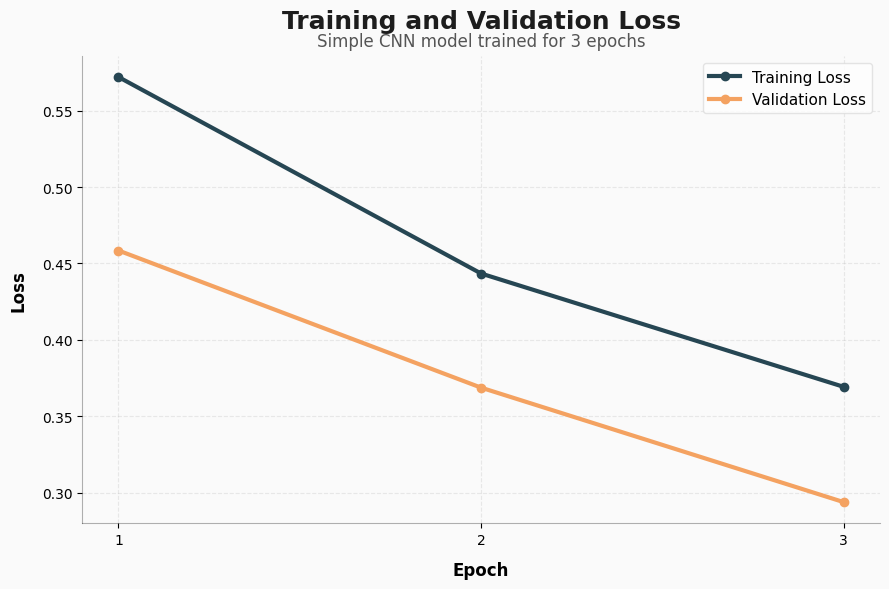

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.plot(
    history_df.index + 1,
    history_df["loss"],
    marker="o",
    linewidth=3,
    label="Training Loss",
    color="#264653"
)

ax.plot(
    history_df.index + 1,
    history_df["val_loss"],
    marker="o",
    linewidth=3,
    label="Validation Loss",
    color="#F4A261"
)

ax.set_title(
    "Training and Validation Loss",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Simple CNN model trained for 3 epochs",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_xlabel("Epoch", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Loss", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xticks(history_df.index + 1)

ax.grid(True, linestyle="--", alpha=0.25)

ax.legend(
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#DDDDDD"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.tight_layout()
plt.show()

## Loss curve interpretation

The loss curve shows that both training loss and validation loss decrease during the first three epochs.

This means that the model is learning and making fewer errors over time.  
There are no clear signs of overfitting in this first short training run, because the validation loss continues to decrease.

The result suggests that the simple CNN model is a good baseline model for this classification task.

In [23]:
fig.savefig(
    FIGURES_DIR / "simple_cnn_accuracy.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

In [24]:
fig.savefig(
    FIGURES_DIR / "simple_cnn_loss.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

In [25]:
val_loss, val_accuracy = model.evaluate(validation_dataset)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.8746 - loss: 0.2938
Validation Loss: 0.2938
Validation Accuracy: 0.8746


## Baseline model evaluation

The simple CNN model achieved a validation accuracy of 87.46% and a validation loss of 0.2938.

This means that the model correctly classified about 87% of the validation images.  
For a first baseline CNN model trained for only three epochs, this is a strong result.

The model can still be improved further by using techniques such as data augmentation, dropout and early stopping.

In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [27]:
# Create predictions for the validation dataset

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype("int32")
    
    y_true.extend(labels.numpy().astype("int32").flatten())
    y_pred.extend(predicted_labels.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of true labels:", len(y_true))
print("Number of predicted labels:", len(y_pred))
print("First 10 true labels:", y_true[:10])
print("First 10 predicted labels:", y_pred[:10])

Number of true labels: 8000
Number of predicted labels: 8000
First 10 true labels: [0 0 0 0 0 0 0 0 0 0]
First 10 predicted labels: [0 0 1 0 0 0 1 0 0 0]


In [28]:
cm = confusion_matrix(y_true, y_pred)

cm

array([[3423,  577],
       [ 426, 3574]])

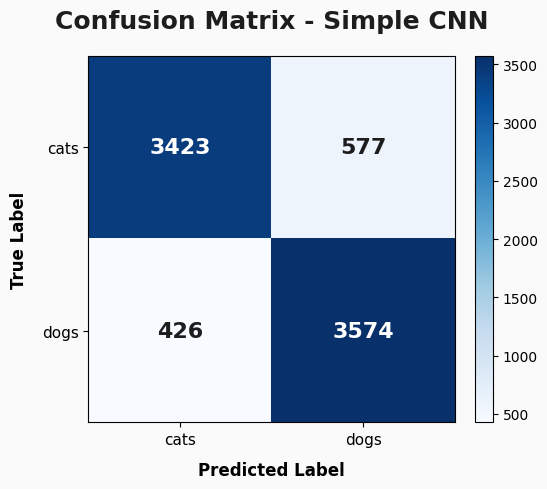

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

im = ax.imshow(cm, cmap="Blues")

ax.set_title(
    "Confusion Matrix - Simple CNN",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#1D1D1D"
)

ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(class_names, fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if cm[i, j] > cm.max() / 2 else "#1D1D1D"
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "simple_cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

## Confusion matrix interpretation

The confusion matrix shows that the model correctly classified 3,423 cat images and 3,574 dog images.

The model misclassified 577 cat images as dogs and 426 dog images as cats.  
This means that the model made slightly more mistakes on cat images than on dog images.

Overall, the model correctly classified 6,997 out of 8,000 validation images, which matches the validation accuracy of 87.46%.

The result shows that the simple CNN model performs well as a baseline, but there is still room for improvement.

In [30]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

        cats       0.89      0.86      0.87      4000
        dogs       0.86      0.89      0.88      4000

    accuracy                           0.87      8000
   macro avg       0.88      0.87      0.87      8000
weighted avg       0.88      0.87      0.87      8000



## Classification report interpretation

The classification report shows that the simple CNN model performs well on both classes.

For cats, the model achieved a precision of 0.89, recall of 0.86 and F1-score of 0.87.  
For dogs, the model achieved a precision of 0.86, recall of 0.89 and F1-score of 0.88.

The results are balanced between the two classes, which means the model does not strongly favor one class over the other.  
However, the recall is slightly higher for dogs than for cats, which means the model identifies dog images a little better.

Overall, the model achieved an accuracy of 87%, which is a strong baseline result for a first simple CNN model.

In [31]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model.save(MODELS_DIR / "simple_cnn_model.keras")

In [32]:
print("Model saved to:", MODELS_DIR / "simple_cnn_model.keras")

Model saved to: c:\Users\mahta\aidev\cats-dogs-cnn-classifier\models\simple_cnn_model.keras


## Baseline conclusion

The first simple CNN model achieved a validation accuracy of 87.46%.

The training and validation curves show that the model improved during the first three epochs.  
Both training loss and validation loss decreased, which means the model learned useful visual patterns from the images.

The confusion matrix and classification report show that the model performs well on both cats and dogs.  
The model classified dogs slightly better than cats, but the overall performance is balanced.

This simple CNN model is a strong baseline.  
However, the model can still be improved by using techniques such as:

- Data augmentation
- Dropout
- Early stopping
- More training epochs
- A more advanced CNN architecture

The next step is to build an improved CNN model and compare it with this baseline model.